In [276]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest
from sklearn.preprocessing import StandardScaler

In [277]:
train = pd.read_csv("../dataset/pre_processed/train_preprocessed.csv")
test = pd.read_csv("../dataset/pre_processed/test_preprocessed.csv")

In [278]:
train.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,4.110874,RL,65.0,8450.0,Pave,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5.0,2003,2003,Gable,CompShg,VinylSd,VinylSd,5.283204,Gd,TA,PConc,Gd,TA,No,GLQ,706.0,Unf,0,150.0,856,GasA,Ex,Y,SBrkr,856.0,854,0,1710.0,1.0,0,2,1,3.0,1,Gd,8,Typ,0.0,Attchd,2003.0,RFn,2.0,548.0,TA,TA,Y,0.000000,4.127134,0,0,0,0,0,2,2008,WD,Normal,208500.0
1,2,3.044522,RL,80.0,9600.0,Pave,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,7.5,1976,1976,Gable,CompShg,MetalSd,MetalSd,0.000000,TA,TA,CBlock,Gd,TA,Gd,ALQ,978.0,Unf,0,284.0,1262,GasA,Ex,Y,SBrkr,1262.0,0,0,1262.0,0.0,0,2,0,3.0,1,TA,6,Typ,1.0,Attchd,1976.0,RFn,2.0,460.0,TA,TA,Y,5.700444,0.000000,0,0,0,0,0,5,2007,WD,Normal,181500.0
2,3,4.110874,RL,68.0,11250.0,Pave,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5.0,2001,2002,Gable,CompShg,VinylSd,VinylSd,5.093750,Gd,TA,PConc,Gd,TA,Mn,GLQ,486.0,Unf,0,434.0,920,GasA,Ex,Y,SBrkr,920.0,866,0,1786.0,1.0,0,2,1,3.0,1,Gd,6,Typ,1.0,Attchd,2001.0,RFn,2.0,608.0,TA,TA,Y,0.000000,3.761200,0,0,0,0,0,9,2008,WD,Normal,223500.0
3,4,4.262680,RL,60.0,9550.0,Pave,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5.0,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,0.000000,TA,TA,BrkTil,TA,Gd,No,ALQ,216.0,Unf,0,540.0,756,GasA,Gd,Y,SBrkr,961.0,756,0,1717.0,1.0,0,1,0,3.0,1,Gd,7,Typ,1.0,Detchd,1998.0,Unf,3.0,642.0,TA,TA,Y,0.000000,3.583519,0,0,0,0,0,2,2006,WD,Abnorml,140000.0
4,5,4.110874,RL,84.0,14260.0,Pave,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5.0,2000,2000,Gable,CompShg,VinylSd,VinylSd,5.860786,Gd,TA,PConc,Gd,TA,Av,GLQ,655.0,Unf,0,490.0,1145,GasA,Ex,Y,SBrkr,1145.0,1053,0,2198.0,1.0,0,2,1,4.0,1,Gd,9,Typ,1.0,Attchd,2000.0,RFn,3.0,836.0,TA,TA,Y,5.262690,4.442651,0,0,0,0,0,12,2008,WD,Normal,250000.0


In [279]:
train["TotalSF"] = (
    train["TotalBsmtSF"] +
    train["1stFlrSF"] +
    train["2ndFlrSF"]
)

test["TotalSF"] = (
    test["TotalBsmtSF"] +
    test["1stFlrSF"] +
    test["2ndFlrSF"]
)

In [280]:
train["HouseAge"] = (
    train["YrSold"] -
    train["YearBuilt"]
)

test["HouseAge"] = (
    test["YrSold"] -
    test["YearBuilt"]
)

In [281]:
train["RemodelAge"] = (
    train["YrSold"] -
    train["YearRemodAdd"]
)

test["RemodelAge"] = (
    test["YrSold"] -
    test["YearRemodAdd"]
)

In [282]:
train["TotalBath"] = (
    train["FullBath"] +
    (0.5 * train["HalfBath"]) +
    train["BsmtFullBath"] +
    (0.5 * train["BsmtHalfBath"])
)

test["TotalBath"] = (
    test["FullBath"] +
    (0.5 * test["HalfBath"]) +
    test["BsmtFullBath"] +
    (0.5 * test["BsmtHalfBath"])
)

In [283]:
train["TotalPorchSF"] = (
    train["OpenPorchSF"] +
    train["EnclosedPorch"] +
    train["3SsnPorch"] +
    train["ScreenPorch"]
)

test["TotalPorchSF"] = (
    test["OpenPorchSF"] +
    test["EnclosedPorch"] +
    test["3SsnPorch"] +
    test["ScreenPorch"]
)

In [284]:
numerical_columns = train.select_dtypes(include=["int64","float64"]).columns

numerical_columns

Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice', 'TotalSF', 'HouseAge',
       'RemodelAge', 'TotalBath', 'TotalPorchSF'],
      dtype='str')

In [285]:
categorical_column = train.select_dtypes(include="object").columns

categorical_column

/tmp/ipykernel_450149/1398324780.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_column = train.select_dtypes(include="object").columns


Index(['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional',
       'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
       'SaleType', 'SaleCondition'],
      dtype='str')

## One Hot encoding

In [286]:
train = pd.get_dummies(train, drop_first=True, dtype = int)

In [287]:
train

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice,TotalSF,HouseAge,...,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,1,4.110874,65.0,8450.0,7,5.0,2003,2003,5.283204,706.0,0,150.0,856,856.0,854,0,1710.0,1.0,0,2,1,3.0,1,8,0.0,2003.0,2.0,548.0,0.000000,4.127134,0,0,0,0,0,2,2008,208500.0,2566.0,5,...,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
1,2,3.044522,80.0,9600.0,6,7.5,1976,1976,0.000000,978.0,0,284.0,1262,1262.0,0,0,1262.0,0.0,0,2,0,3.0,1,6,1.0,1976.0,2.0,460.0,5.700444,0.000000,0,0,0,0,0,5,2007,181500.0,2524.0,31,...,1,0,0,1,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
2,3,4.110874,68.0,11250.0,7,5.0,2001,2002,5.093750,486.0,0,434.0,920,920.0,866,0,1786.0,1.0,0,2,1,3.0,1,6,1.0,2001.0,2.0,608.0,0.000000,3.761200,0,0,0,0,0,9,2008,223500.0,2706.0,7,...,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
3,4,4.262680,60.0,9550.0,7,5.0,1915,1970,0.000000,216.0,0,540.0,756,961.0,756,0,1717.0,1.0,0,1,0,3.0,1,7,1.0,1998.0,3.0,642.0,0.000000,3.583519,0,0,0,0,0,2,2006,140000.0,2473.0,91,...,1,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0
4,5,4.110874,84.0,14260.0,8,5.0,2000,2000,5.860786,655.0,0,490.0,1145,1145.0,1053,0,2198.0,1.0,0,2,1,4.0,1,9,1.0,2000.0,3.0,836.0,5.262690,4.442651,0,0,0,0,0,12,2008,250000.0,3343.0,8,...,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,4.110874,62.0,7917.0,6,5.0,1999,2000,0.000000,0.0,0,953.0,953,953.0,694,0,1647.0,0.0,0,2,1,3.0,1,7,1.0,1999.0,2.0,460.0,0.000000,3.713572,0,0,0,0,0,8,2007,175000.0,2600.0,8,...,1,0,0,1,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
1456,1457,3.044522,85.0,13175.0,6,6.0,1978,1988,4.787492,790.0,0,589.0,1542,2073.0,0,0,2073.0,1.0,0,2,0,3.0,1,7,2.0,1978.0,2.0,500.0,5.857933,0.000000,0,0,0,0,0,2,2010,210000.0,3615.0,32,...,1,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
1457,1458,4.262680,66.0,9042.0,7,7.5,1941,2006,0.000000,275.0,0,877.0,1152,1188.0,1152,0,2340.0,0.0,0,2,0,4.0,1,9,2.0,1941.0,1.0,252.0,0.000000,4.110874,0,0,0,0,0,5,2010,266500.0,3492.0,69,...,1,0,1,0,0,0,0,0,0,1,1,0,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0
1458,1459,3.044522,68.0,9717.0,5,6.0,1950,1996,0.000000,49.0,0,0.0,1078,1078.0,0,0,1078.0,1.0,0,1,0,2.0,1,5,0.0,1950.0,1.0,240.0,5.905362,0.000000,0,0,0,0,0,4,2010,142125.0,2156.0,60,...,0,0,1,0,0,0,0,0,0,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,1,0,0,0,1,0


In [288]:
y = train["SalePrice"]
x = train.drop("SalePrice", axis=1)

# Scalaing

In [289]:
scaler = StandardScaler()

In [290]:
train_scaled = scaler.fit_transform(x)

In [291]:
train_scaled

array([[-1.73086488,  0.45463051, -0.23745555, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [-1.7284922 , -1.14381284,  0.63332083, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [-1.72611953,  0.45463051, -0.06330027, ..., -0.11785113,
         0.4676514 , -0.30599503],
       ...,
       [ 1.72611953,  0.68218524, -0.17940379, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [ 1.7284922 , -1.14381284, -0.06330027, ..., -0.11785113,
         0.4676514 , -0.30599503],
       [ 1.73086488, -1.14381284,  0.34306204, ..., -0.11785113,
         0.4676514 , -0.30599503]], shape=(1460, 235))

In [292]:
train_scaled = pd.DataFrame(train_scaled, columns=x.columns)
train_scaled

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,TotalSF,HouseAge,RemodelAge,...,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,-1.730865,0.454631,-0.237456,-0.333244,0.652644,-0.564161,1.053246,0.878668,1.230517,0.614224,0.0,-0.958790,-0.488321,-0.830489,1.164283,0.0,0.428636,1.111765,0.0,0.789741,1.227585,0.195307,0.0,0.981148,-0.957043,1.017824,0.315946,0.373509,-0.947396,0.863737,0.0,0.0,0.0,0.0,0.0,-1.599111,0.138777,0.015826,-1.045496,-0.869941,...,0.305995,-0.165667,1.221257,-1.006873,-0.058621,-0.147287,-0.154412,-0.101885,-0.02618,0.271163,0.731591,-0.114827,-0.253259,-0.078757,-0.600559,1.568348,-0.941438,-0.184376,-0.098397,-0.045376,0.221022,-0.156721,-0.078757,-0.069409,0.194085,-0.144841,0.299253,-0.052414,-0.037037,-0.078757,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,0.467651,-0.305995
1,-1.728492,-1.143813,0.633321,-0.013189,-0.073068,2.030907,0.156179,-0.429577,-0.809621,1.242296,0.0,-0.648290,0.532289,0.289638,-0.796041,0.0,-0.502349,-0.821739,0.0,0.789741,-0.761621,0.195307,0.0,-0.316385,0.608540,-0.108062,0.315946,-0.051541,1.254734,-1.077559,0.0,0.0,0.0,0.0,0.0,-0.489110,-0.614439,-0.039853,-0.182997,0.390141,...,0.305995,-0.165667,-0.818829,0.993174,-0.058621,-0.147287,-0.154412,-0.101885,-0.02618,0.271163,0.731591,-0.114827,-0.253259,-0.078757,-0.600559,1.568348,-0.941438,-0.184376,-0.098397,-0.045376,0.221022,-0.156721,-0.078757,-0.069409,0.194085,-0.144841,0.299253,-0.052414,-0.037037,-0.078757,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,0.467651,-0.305995
2,-1.726120,0.454631,-0.063300,0.446022,0.652644,-0.564161,0.986797,0.830215,1.157359,0.106224,0.0,-0.300716,-0.327437,-0.653917,1.191828,0.0,0.586571,1.111765,0.0,0.789741,1.227585,0.195307,0.0,-0.316385,0.608540,0.934425,0.315946,0.663315,-0.947396,0.691611,0.0,0.0,0.0,0.0,0.0,0.990891,0.138777,0.201422,-0.979149,-0.821476,...,0.305995,-0.165667,1.221257,-1.006873,-0.058621,-0.147287,-0.154412,-0.101885,-0.02618,0.271163,0.731591,-0.114827,-0.253259,-0.078757,-0.600559,1.568348,-0.941438,-0.184376,-0.098397,-0.045376,0.221022,-0.156721,-0.078757,-0.069409,0.194085,-0.144841,0.299253,-0.052414,-0.037037,-0.078757,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,0.467651,-0.305995
3,-1.723747,0.682185,-0.527714,-0.027104,0.652644,-0.564161,-1.870528,-0.720298,-0.809621,-0.517230,0.0,-0.055097,-0.739702,-0.540801,0.939328,0.0,0.443182,1.111765,0.0,-1.026041,-0.761621,0.195307,0.0,0.332382,0.608540,0.809327,1.662750,0.827539,-0.947396,0.608034,0.0,0.0,0.0,0.0,0.0,-1.599111,-1.367655,-0.107463,1.807384,0.632464,...,0.305995,-0.165667,1.221257,-1.006873,-0.058621,-0.147287,-0.154412,-0.101885,-0.02618,0.271163,-1.366883,-0.114827,-0.253259,-0.078757,1.665116,-0.637614,1.062205,-0.184376,-0.098397,-0.045376,0.221022,-0.156721,-0.078757,-0.069409,0.194085,-0.144841,0.299253,-0.052414,-0.037037,-0.078757,-0.058621,-0.058621,-0.301962,-0.045376,0.390293,-0.052414,-0.091035,-0.117851,-2.138345,-0.305995
4,-1.721374,0.454631,0.865528,1.28373

In [293]:
skewness = train_scaled.skew()

skewness

Id                        0.000000
MSSubClass                0.142088
LotFrontage               0.094443
LotArea                   0.208492
OverallQual               0.249513
                           ...    
SaleCondition_AdjLand    19.045943
SaleCondition_Alloca     10.905010
SaleCondition_Family      8.376038
SaleCondition_Normal     -1.672412
SaleCondition_Partial     2.965079
Length: 235, dtype: float64

In [294]:
skewed_columns = skewness[skewness.abs() > 1].index
for column in skewed_columns:
    train_scaled[column] = np.log1p(train_scaled[column])

/home/aximsoft/snap/code/248/.local/share/virtualenvs/Advanced_Regression_Model_Comparison___Opt-A-6IYopj/lib/python3.13/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [295]:
skewness = train_scaled.skew()
skewness

Id                        0.000000
MSSubClass                0.142088
LotFrontage               0.094443
LotArea                   0.208492
OverallQual               0.249513
                           ...    
SaleCondition_AdjLand    19.045943
SaleCondition_Alloca     10.905010
SaleCondition_Family      8.376038
SaleCondition_Normal      0.000000
SaleCondition_Partial     2.965079
Length: 235, dtype: float64

In [296]:
correlation = train.corr(numeric_only=True)["SalePrice"]

correlation.sort_values(ascending=False)

SalePrice        1.000000
TotalSF          0.821885
OverallQual      0.817680
GrLivArea        0.729311
GarageCars       0.675896
                   ...   
EnclosedPorch         NaN
3SsnPorch             NaN
ScreenPorch           NaN
PoolArea              NaN
MiscVal               NaN
Name: SalePrice, Length: 236, dtype: float64

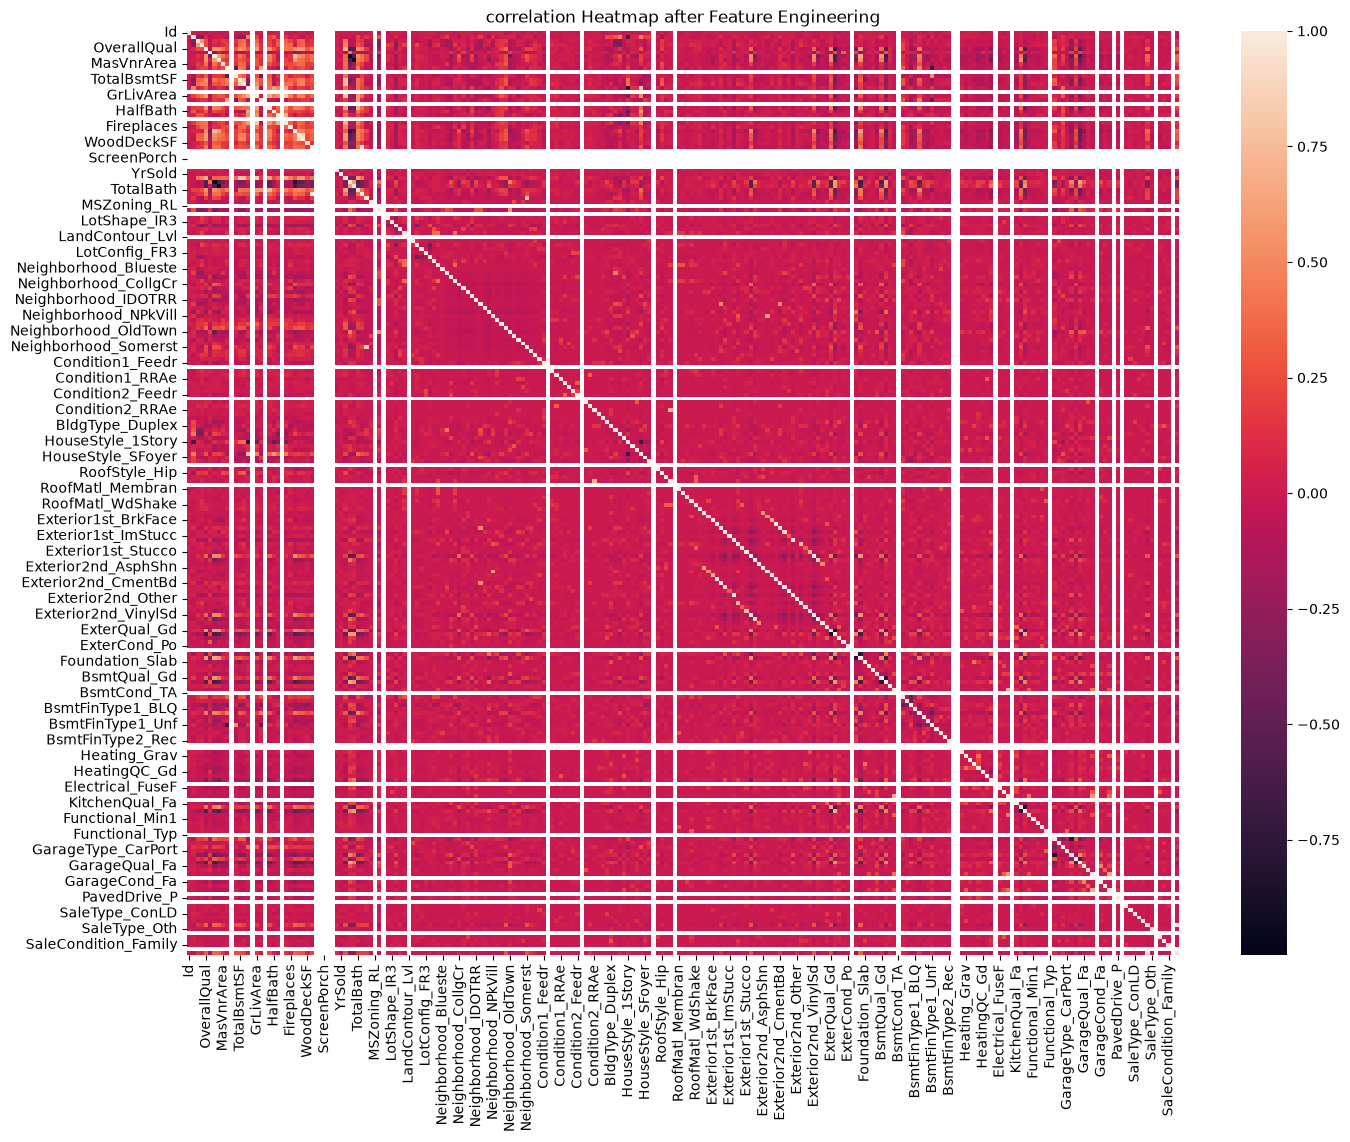

In [297]:
plt.figure(figsize=(16,12))

sns.heatmap(train_scaled.corr())

plt.title("correlation Heatmap after Feature Engineering")
plt.show()

In [298]:
correlation = correlation[correlation > 0.50]

In [299]:
correlation

OverallQual         0.817680
YearBuilt           0.570327
YearRemodAdd        0.552061
TotalBsmtSF         0.645251
1stFlrSF            0.621873
GrLivArea           0.729311
FullBath            0.583994
TotRmsAbvGrd        0.539339
GarageCars          0.675896
GarageArea          0.660029
SalePrice           1.000000
TotalSF             0.821885
TotalBath           0.657381
ExterQual_Gd        0.526232
Foundation_PConc    0.535107
Name: SalePrice, dtype: float64

In [300]:
selected_features = [
    "OverallQual","YearBuilt","YearRemodAdd","TotalBsmtSF","1stFlrSF","GrLivArea",
    "FullBath","TotRmsAbvGrd","GarageCars","GarageArea","TotalSF","TotalBath","ExterQual_Gd","Foundation_PConc"
]

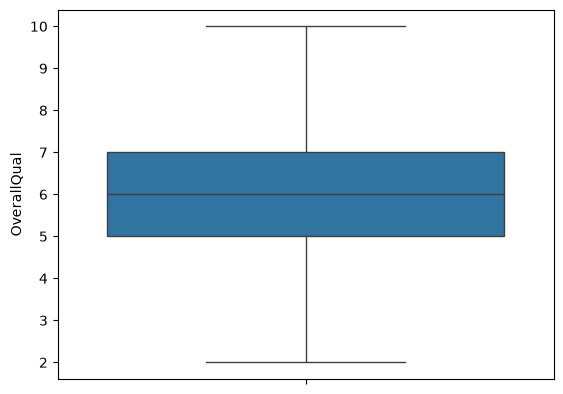

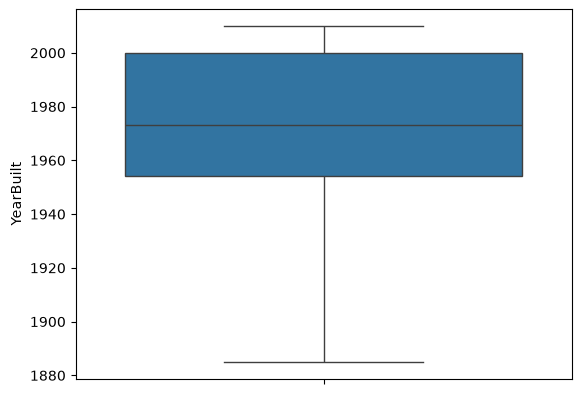

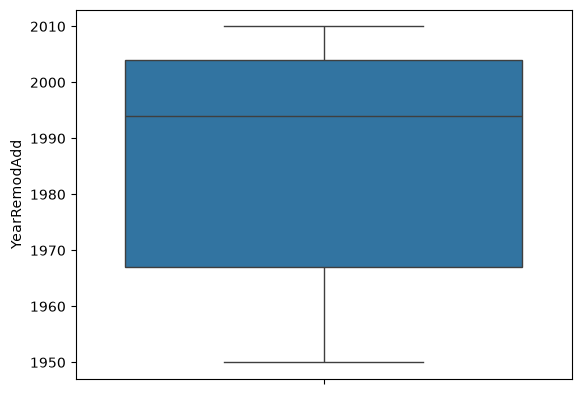

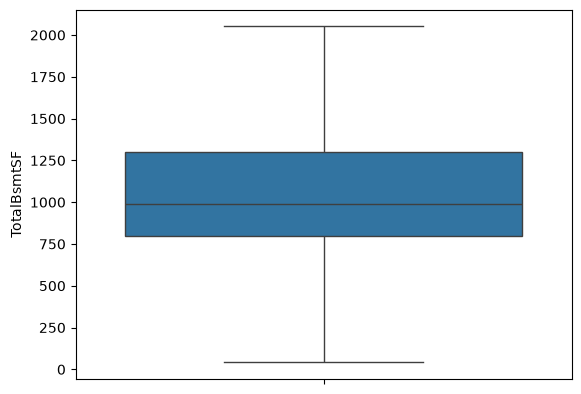

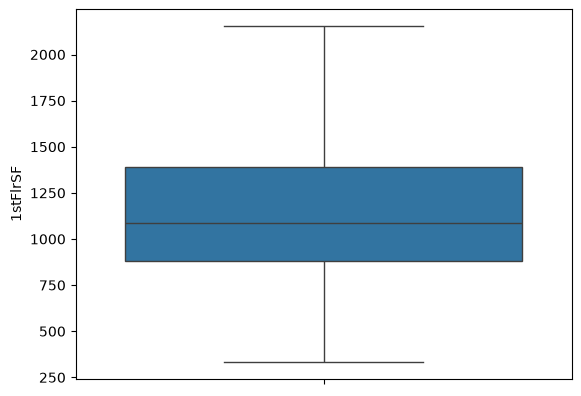

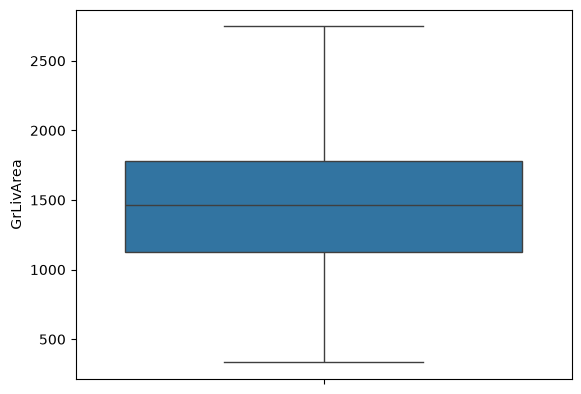

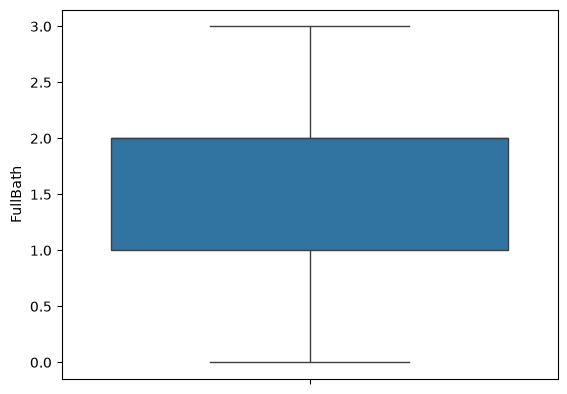

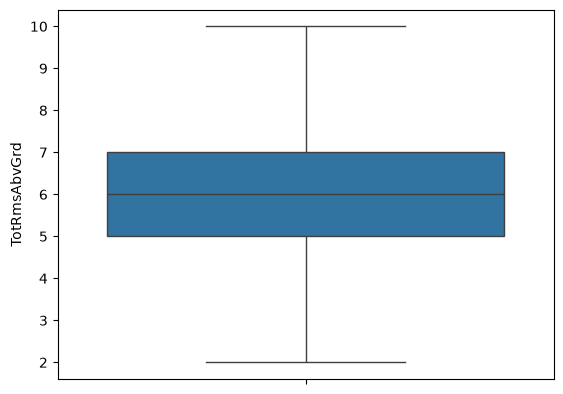

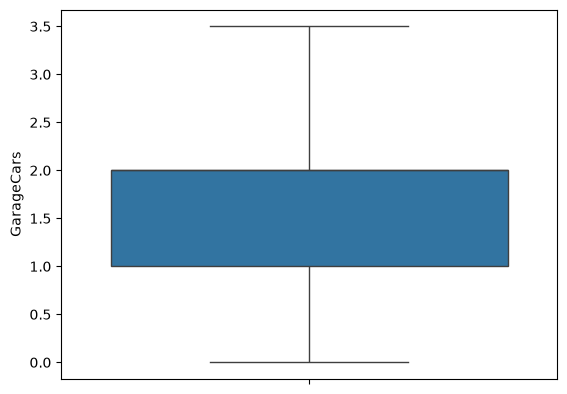

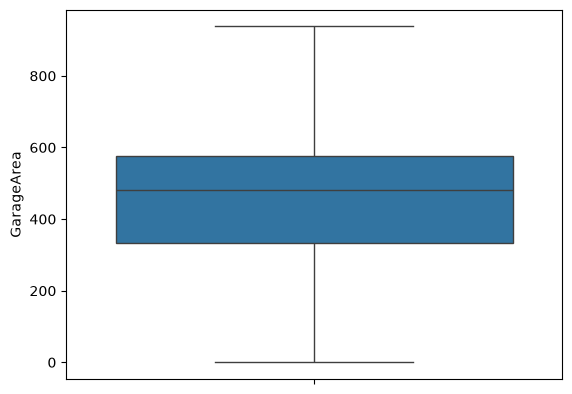

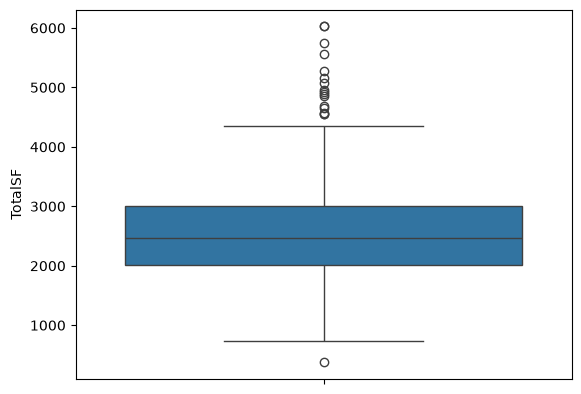

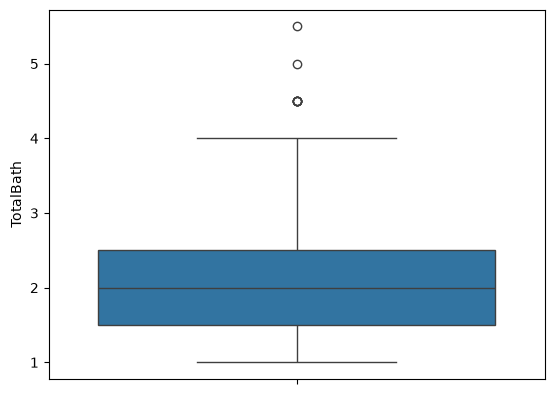

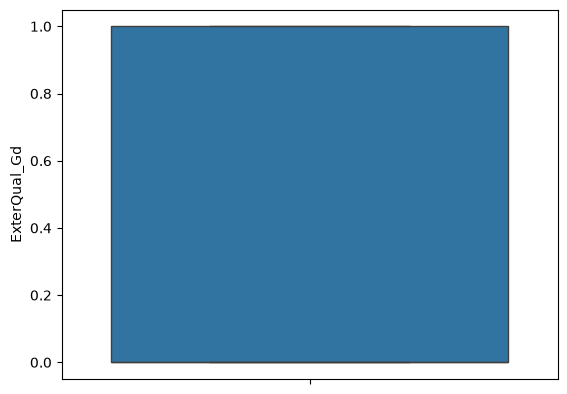

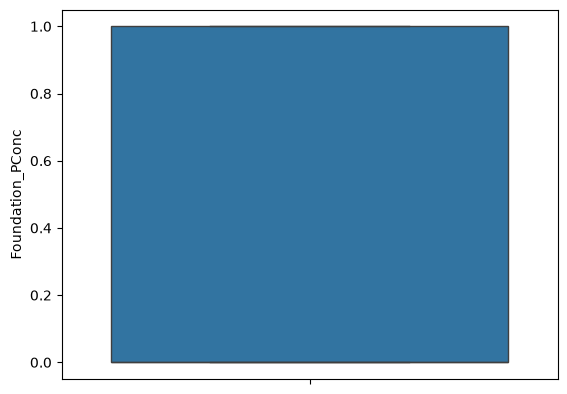

In [301]:
for column in selected_features:

    sns.boxplot(y=train[column])

    plt.show()

In [306]:
from statsmodels.stats.outliers_influence import variance_inflation_factor